# Three-PDE Drug Release Model using the Method of Lines (MOL)

1. Divide the spatial domain into discrete grid points.
2. Approximate spatial derivatives using finite differences.
3. Convert the PDE system into a large system of ordinary differential equations (ODEs).
4. Integrate the resulting ODE system using SciPy's `solve_ivp`.


In [57]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import numpy as np
# solve_ivp integrates the system of ODEs produced by the
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Model Parameters


In [58]:
# ==========================================================
# Model Parameters
# ==========================================================

# Physical parameters
# Stress generation coefficient
alpha = 0.2
# Stress relaxation coefficient
beta = 1.0
# Coupling coefficient between concentration and stress
gamma = 1.0
# Drug diffusion coefficient
D = 0.6
# Stress diffusion coefficient
E = 0.2
# Boundary mass-transfer coefficient
kr = 1.0

# Drug concentrations
# External drug concentration
ua = 0.0
# Maximum bound concentration
ub = 1.0
# Maximum free concentration
vb = 1.0


# Spatial Grid
# Number of spatial grid points(Same value used in the book)
nx = 26
# Left boundary
xl = -0.5
# Right boundary
xu = 0.5
# Create equally spaced grid
x = np.linspace(xl, xu, nx)
# Grid spacing (Δx)
dx = x[1] - x[0]


# Time Grid
# Initial time
t0 = 0.0
# Final time
tf = 2.0
# Number of output points
nout = 6
# Times where the solver stores the solution
t_eval = np.linspace(t0, tf, nout)

# Binding and Unbinding Rate Functions

- **f_u(u,v)** : Rate of change of the free drug concentration.
- **g_v(u,v)** : Rate of change of the bound drug concentration.


In [59]:
# ==========================================================
# Reaction (Binding / Unbinding) Functions
# ==========================================================

def f_u(ub, vb, u, v):

    binding = u * (ub - u)

    unbinding = v * (vb - v)

    return -binding + unbinding


def g_v(ub, vb, u, v):

    binding = u * (ub - u)

    unbinding = v * (vb - v)

    return binding - unbinding

In [60]:
u_test = 0.60
v_test = 0.20

print("f_u =", f_u(ub, vb, u_test, v_test))
print("g_v =", g_v(ub, vb, u_test, v_test))

print("Sum =", f_u(ub, vb, u_test, v_test) +
               g_v(ub, vb, u_test, v_test))

f_u = -0.07999999999999996
g_v = 0.07999999999999996
Sum = 0.0


# Spatial Derivative Approximation (`dss004`)


In [61]:
def dss004(xl, xu, nx, y):

    # Compute the spatial step size

    dx = (xu - xl) / (nx - 1)

    # Allocate memory for the derivative

    dy_dx = np.zeros(nx)


    for i in range(1, nx - 1):

        dy_dx[i] = (y[i + 1] - y[i - 1]) / (2 * dx)

    # Left Boundary
    dy_dx[0] = (y[1] - y[0]) / dx

    # Right Boundary
    dy_dx[-1] = (y[-1] - y[-2]) / dx

    return dy_dx

In [62]:
# ==========================================================
# Test the Spatial Derivative
# ==========================================================

# Test function
y = x**2

# Numerical derivative
dy_num = dss004(xl, xu, nx, y)

# Exact derivative
dy_exact = 2 * x

# Display comparison
print("      x      Numerical     Exact")

for xi, num, exact in zip(x, dy_num, dy_exact):
    print(f"{xi:8.3f} {num:12.5f} {exact:12.5f}")

      x      Numerical     Exact
  -0.500     -0.96000     -1.00000
  -0.460     -0.92000     -0.92000
  -0.420     -0.84000     -0.84000
  -0.380     -0.76000     -0.76000
  -0.340     -0.68000     -0.68000
  -0.300     -0.60000     -0.60000
  -0.260     -0.52000     -0.52000
  -0.220     -0.44000     -0.44000
  -0.180     -0.36000     -0.36000
  -0.140     -0.28000     -0.28000
  -0.100     -0.20000     -0.20000
  -0.060     -0.12000     -0.12000
  -0.020     -0.04000     -0.04000
   0.020      0.04000      0.04000
   0.060      0.12000      0.12000
   0.100      0.20000      0.20000
   0.140      0.28000      0.28000
   0.180      0.36000      0.36000
   0.220      0.44000      0.44000
   0.260      0.52000      0.52000
   0.300      0.60000      0.60000
   0.340      0.68000      0.68000
   0.380      0.76000      0.76000
   0.420      0.84000      0.84000
   0.460      0.92000      0.92000
   0.500      0.96000      1.00000


# ODE Routine: `drug_1`

1. Extract the variables **u**, **v**, and **s** from the combined solution vector.
2. Compute the first spatial derivatives.
3. Apply the boundary conditions.
4. Compute the second spatial derivatives.
5. Evaluate the PDEs at every spatial node.
6. Combine the results into a single vector and return it.

In [63]:
# This variable counts how many times the ODE solver calls
ncall = 0


# ==========================================================
# Method of Lines ODE Routine
# ==========================================================

def drug_1(t, U):
    """
    Computes dU/dt for the Method of Lines.

    """

    global ncall

    # Split the state vector into the three PDE variables
    u = U[:nx]
    v = U[nx:2*nx]
    s = U[2*nx:3*nx]

    # Compute first spatial derivatives

    ux = dss004(xl, xu, nx, u)
    sx = dss004(xl, xu, nx, s)

    # Apply Boundary Conditions

    ux[0] = -(kr / D) * (ua - u[0])
    ux[-1] = (kr / D) * (ua - u[-1])

    # Homogeneous Neumann BC for stress

    sx[0] = 0.0
    sx[-1] = 0.0

    # Compute second derivatives
    # Stagewise differentiation:


    uxx = dss004(xl, xu, nx, ux)
    sxx = dss004(xl, xu, nx, sx)

    # Allocate memory for the time derivatives

    ut = np.zeros(nx)
    vt = np.zeros(nx)
    st = np.zeros(nx)

    # Evaluate the PDEs

    for i in range(nx):
        ut[i] = (
            D * uxx[i]
            + E * sxx[i]
            + f_u(ub, vb, u[i], v[i])
        )

        vt[i] = g_v(ub, vb, u[i], v[i])

        st[i] = (
            alpha * u[i]
            - beta * s[i]
            + gamma * ut[i]
        )

    dUdt = np.concatenate((ut, vt, st))


    ncall += 1

    return dUdt

# Initial Conditions and State Vector

Before solving the PDE system, we must define the initial values of all
unknown variables.

The book specifies the following initial conditions:

\[
u(x,0)=0.75
\]

\[
v(x,0)=0.25
\]

\[
s(x,0)=0
\]

for every point in the spatial domain.

---



In [64]:
# ==========================================================
# Initial Conditions
# ==========================================================


u0 = np.full(nx, 0.75)
v0 = np.full(nx, 0.25)
s0 = np.zeros(nx)
U0 = np.concatenate((u0, v0, s0))

# ----------------------------------------------------------
# Verify the size of the system.
# ----------------------------------------------------------


print(f"Number of spatial nodes : {nx}")
print(f"Unknowns per node       : 3")
print(f"Total ODEs             : {len(U0)}")


Number of spatial nodes : 26
Unknowns per node       : 3
Total ODEs             : 78


# Solving the System of ODEs

After discretizing the PDEs using the Method of Lines (MOL),
we obtain a system of ordinary differential equations (ODEs).

For this problem:

- Number of spatial nodes = 26
- Variables at each node = 3

Therefore,

\[
26 \times 3 = 78
\]

ODEs must be solved simultaneously.


In [65]:
# Integrate the Method of Lines system.


solution = solve_ivp(
    fun=drug_1,          # Function computing dU/dt
    t_span=(t0, tf),     # Time interval
    y0=U0,               # Initial condition vector
    t_eval=t_eval,       # Times where the solution is stored
    method="RK45"        # Adaptive Runge-Kutta solver
)

print("Integration complete.")


# Check whether the solver succeeded.
if solution.success:
    print("Solver Status : SUCCESS")
else:
    print("Solver Status : FAILED")

print("\nSolver Message:")
print(solution.message)

print("\nNumber of function evaluations:")
print(solution.nfev)

print("\nNumber of stored time points:")
print(len(solution.t))

print("\nShape of solution matrix:")
print(solution.y.shape)



Integration complete.
Solver Status : SUCCESS

Solver Message:
The solver successfully reached the end of the integration interval.

Number of function evaluations:
2162

Number of stored time points:
6

Shape of solution matrix:
(78, 6)


# Organizing the Numerical Solution

After the ODE solver finishes, all solution variables are stored in a
single matrix:

- Rows correspond to the unknown variables.
- Columns correspond to different output times.



In [66]:
# Organize the Numerical Solution


u_xplot = solution.y[:nx, :]
v_xplot = solution.y[nx:2*nx, :]
s_xplot = solution.y[2*nx:3*nx, :]

print("\nExtracted Solution Arrays")

print(f"u_xplot shape : {u_xplot.shape}")
print(f"v_xplot shape : {v_xplot.shape}")
print(f"s_xplot shape : {s_xplot.shape}")



Extracted Solution Arrays
u_xplot shape : (26, 6)
v_xplot shape : (26, 6)
s_xplot shape : (26, 6)


# Display Numerical Results


In [67]:
# Display Numerical Solution
# Indices corresponding to the first and last output times
time_indices = [0, -1]

for idx in time_indices:

    print(f"Numerical Solution at t = {solution.t[idx]:.2f}")

    # Print table header
    print(f"{'x':>8} {'u(x,t)':>15} {'v(x,t)':>15} {'s(x,t)':>15}")

    # Print each spatial node
    for i in range(nx):

        print(
            f"{x[i]:8.3f}"
            f"{u_xplot[i, idx]:15.6f}"
            f"{v_xplot[i, idx]:15.6f}"
            f"{s_xplot[i, idx]:15.6f}"
        )

Numerical Solution at t = 0.00
       x          u(x,t)          v(x,t)          s(x,t)
  -0.500       0.750000       0.250000       0.000000
  -0.460       0.750000       0.250000       0.000000
  -0.420       0.750000       0.250000       0.000000
  -0.380       0.750000       0.250000       0.000000
  -0.340       0.750000       0.250000       0.000000
  -0.300       0.750000       0.250000       0.000000
  -0.260       0.750000       0.250000       0.000000
  -0.220       0.750000       0.250000       0.000000
  -0.180       0.750000       0.250000       0.000000
  -0.140       0.750000       0.250000       0.000000
  -0.100       0.750000       0.250000       0.000000
  -0.060       0.750000       0.250000       0.000000
  -0.020       0.750000       0.250000       0.000000
   0.020       0.750000       0.250000       0.000000
   0.060       0.750000       0.250000       0.000000
   0.100       0.750000       0.250000       0.000000
   0.140       0.750000       0.250000       0.0

# Plotting the Numerical Solution


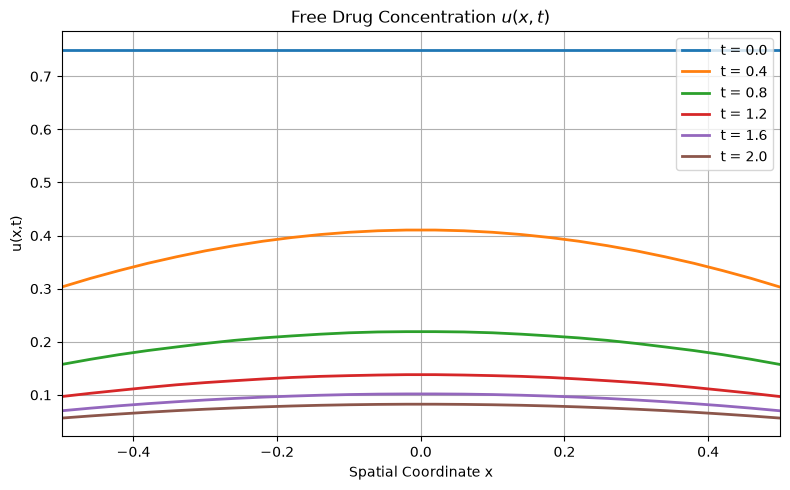

In [68]:
# Plot u(x,t)

plt.figure(figsize=(8, 5))

for i, t in enumerate(solution.t):
    plt.plot(
        x,
        u_xplot[:, i],
        linewidth=2,
        label=f"t = {t:.1f}"
    )

plt.title("Free Drug Concentration $u(x,t)$")

plt.xlabel("Spatial Coordinate x")
plt.ylabel("u(x,t)")

plt.xlim(xl, xu)
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

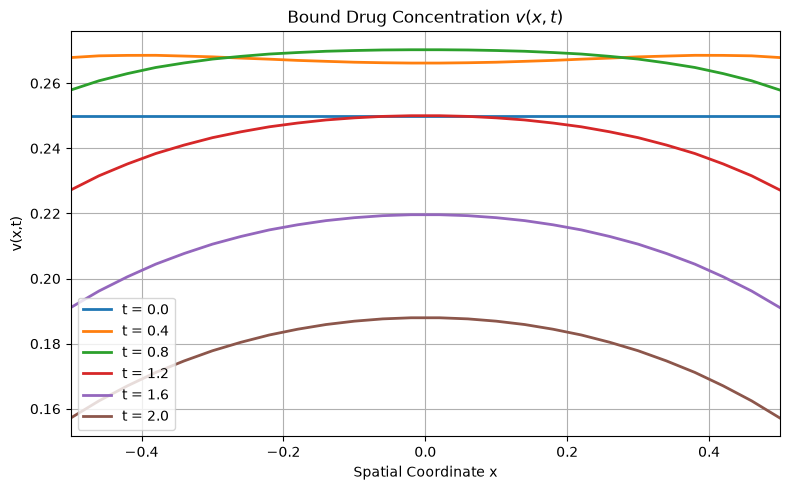

In [69]:
# Plot v(x,t)

plt.figure(figsize=(8, 5))

for i, t in enumerate(solution.t):
    plt.plot(
        x,
        v_xplot[:, i],
        linewidth=2,
        label=f"t = {t:.1f}"
    )

plt.title("Bound Drug Concentration $v(x,t)$")

plt.xlabel("Spatial Coordinate x")

plt.ylabel("v(x,t)")

plt.xlim(xl, xu)
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

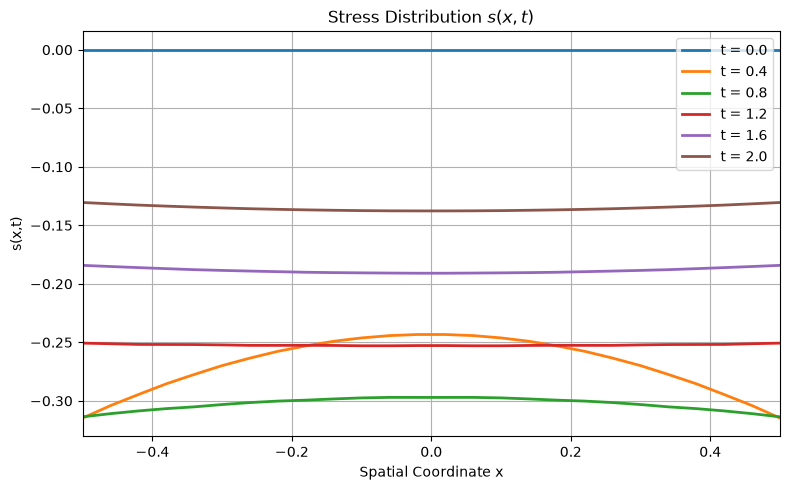

In [70]:
# Plot s(x,t)

plt.figure(figsize=(8, 5))

for i, t in enumerate(solution.t):
    plt.plot(
        x,
        s_xplot[:, i],
        linewidth=2,
        label=f"t = {t:.1f}"
    )

plt.title("Stress Distribution $s(x,t)$")

plt.xlabel("Spatial Coordinate x")

plt.ylabel("s(x,t)")

plt.xlim(xl, xu)
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()